# TP3
- Clément RENIERS
- Louison PARANT


In [78]:
import numpy as np
np.set_printoptions(threshold=10000,suppress=True)
import pandas as pd
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

## Exercice 1

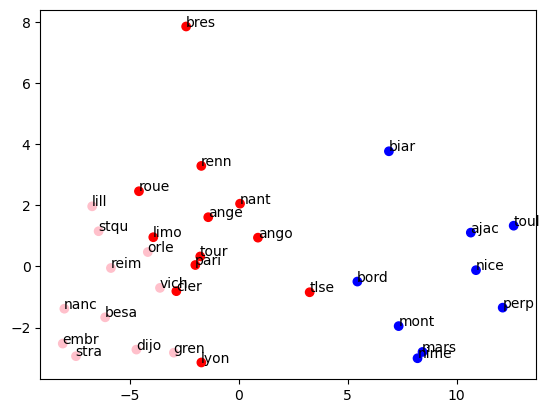

In [79]:
from sklearn.cluster import KMeans
import matplotlib
import matplotlib.pyplot as plt

data = pd.read_csv('./villes.csv', sep=';')
X = data.iloc[:, 1:13].values
labels = data.iloc[:, 0].values

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
clustering = KMeans(n_clusters=3, random_state=0).fit_predict(X_pca)

colors = ['red','yellow','blue','pink']
plt.scatter(X_pca[:, 0], X_pca[:, 1], c= clustering,
cmap=matplotlib.colors.ListedColormap(colors))
for label, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
    plt.annotate(label, xy=(x, y), xytext=(-0.2, 0.2), textcoords='offset points')
plt.show()


## Exercice 2

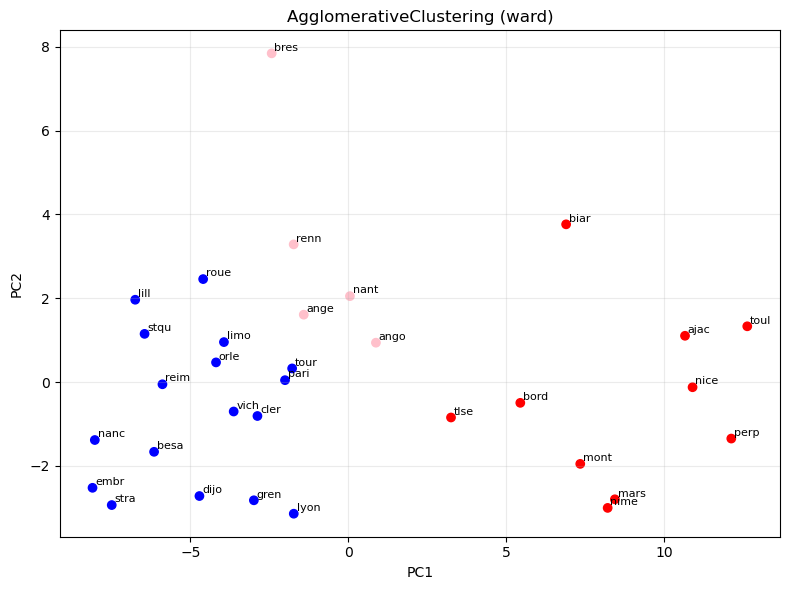

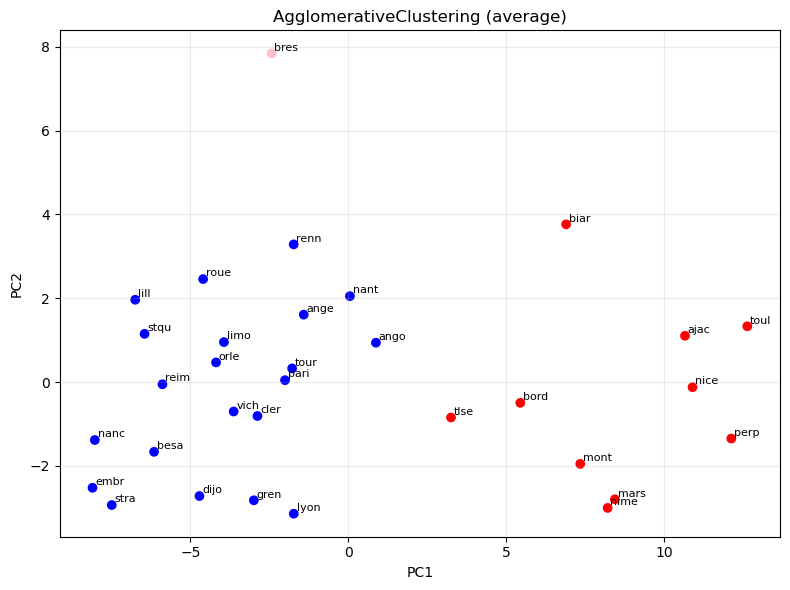

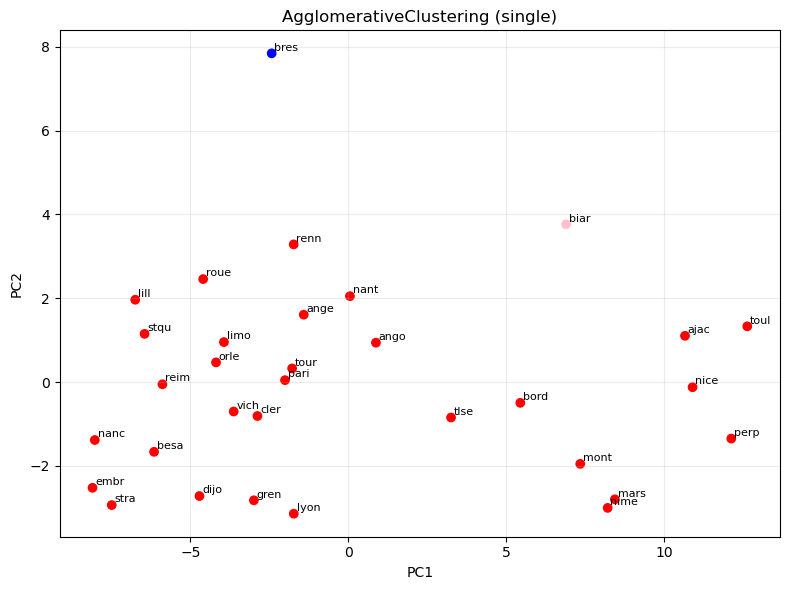

In [80]:
from sklearn.cluster import AgglomerativeClustering

linkages = ['ward', 'average', 'single']
colors = ['red','yellow','blue','pink']

for linkage in linkages:
    fig, ax = plt.subplots(figsize=(8, 6))

    clusters_agg = AgglomerativeClustering(n_clusters=3, linkage=linkage).fit_predict(X)

    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_agg, cmap=matplotlib.colors.ListedColormap(colors))
    for city, xp, yp in zip(labels, X_pca[:, 0], X_pca[:, 1]):
        ax.annotate(city, (xp, yp), textcoords="offset points", xytext=(2, 2), fontsize=8)

    ax.set_title(f"AgglomerativeClustering ({linkage})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


## Exercice 3

In [81]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 7): 
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X)
    silhouette_scores[k] = silhouette_score(X, labels_k)

scores_df = pd.DataFrame(
    {"n_clusters": list(silhouette_scores.keys()),
     "silhouette": list(silhouette_scores.values())}
).sort_values("silhouette", ascending=False)

best_k = scores_df.iloc[0]["n_clusters"]

print(scores_df)

print(f"Meilleure partition pour KMeans : {best_k} clusters")

   n_clusters  silhouette
0           2    0.618116
1           3    0.409120
2           4    0.349404
3           5    0.326583
4           6    0.323984
Meilleure partition pour KMeans : 2.0 clusters


## Exercice 4

In [82]:
silhouette_scores_aggglomerative_ward = {}
silhouette_scores_aggglomerative_average = {}
silhouette_scores_aggglomerative_single = {}

for k in range(2, 7):
    agg_ward = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels_agg_ward = agg_ward.fit_predict(X)
    silhouette_scores_aggglomerative_ward[k] = silhouette_score(X, labels_agg_ward)

    agg_average = AgglomerativeClustering(n_clusters=k, linkage="average")
    labels_agg_average = agg_average.fit_predict(X)
    silhouette_scores_aggglomerative_average[k] = silhouette_score(X, labels_agg_average)

    agg_single = AgglomerativeClustering(n_clusters=k, linkage="single")
    labels_agg_single = agg_single.fit_predict(X)
    silhouette_scores_aggglomerative_single[k] = silhouette_score(X, labels_agg_single)

scores_df_agglomerative = pd.DataFrame(
    {"n_clusters": list(silhouette_scores_aggglomerative_ward.keys()),
     "silhouette_ward": list(silhouette_scores_aggglomerative_ward.values()),
     "silhouette_average": list(silhouette_scores_aggglomerative_average.values()),
     "silhouette_single": list(silhouette_scores_aggglomerative_single.values())}
).sort_values("n_clusters", ascending=True)

best_k_overall = scores_df_agglomerative[["silhouette_ward", "silhouette_average", "silhouette_single"]].max().idxmax()
best_k_value = scores_df_agglomerative.loc[scores_df_agglomerative[best_k_overall] == scores_df_agglomerative[best_k_overall].max(), "n_clusters"].values[0]

print(scores_df_agglomerative)

print(f"Meilleure partition pour AgglomerativeClustering : {best_k_value} clusters avec {best_k_overall}")


   n_clusters  silhouette_ward  silhouette_average  silhouette_single
0           2         0.618116            0.618116           0.165970
1           3         0.406313            0.491728          -0.022192
2           4         0.370212            0.368620           0.205581
3           5         0.300232            0.424060           0.424060
4           6         0.320948            0.343399           0.412634
Meilleure partition pour AgglomerativeClustering : 2 clusters avec silhouette_ward


## Exercice 5

On va faire une fonction pour permettre de calculer ça pour d'autres possibilités

In [83]:
def best_method(X, nb_clusters, cluster_range):
    silhouette_scores_kmeans = {}
    silhouette_scores_agglomerative = {}

    for k in range(*cluster_range):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels_k = km.fit_predict(X)
        silhouette_scores_kmeans[k] = silhouette_score(X, labels_k)

        agg_ward = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels_agg_ward = agg_ward.fit_predict(X)
        silhouette_scores_agglomerative[k] = silhouette_score(X, labels_agg_ward)

        agg_single = AgglomerativeClustering(n_clusters=k, linkage="single")
        labels_agg_single = agg_single.fit_predict(X)
        silhouette_scores_agglomerative[k] = silhouette_score(X, labels_agg_single)

        agg_average = AgglomerativeClustering(n_clusters=k, linkage="average")
        labels_agg_average = agg_average.fit_predict(X)
        silhouette_scores_agglomerative[k] = silhouette_score(X, labels_agg_average)

    score_k_means = silhouette_scores_kmeans[nb_clusters]
    score_agg_ward = silhouette_scores_agglomerative[nb_clusters]
    score_agg_single = silhouette_scores_agglomerative[nb_clusters]
    score_agg_average = silhouette_scores_agglomerative[nb_clusters]

    best_score = max(score_k_means, score_agg_ward, score_agg_single, score_agg_average)
    if best_score == score_k_means:
        return "KMeans", best_score
    elif best_score == score_agg_ward:
        return "Agglomerative (ward)", best_score
    elif best_score == score_agg_single:
        return "Agglomerative (single)", best_score
    else:
        return "Agglomerative (average)", best_score

method, score = best_method(X, nb_clusters=3, cluster_range=(2, 7))
print(f"Meilleure méthode pour 3 clusters : {method}, score: {score:.4f}")


Meilleure méthode pour 3 clusters : Agglomerative (ward), score: 0.4917


## Exercice 6

D'après <https://www.linkedin.com/pulse/comparison-kmeans-agglomerative-clustering-algorithms-jagarlapoodi/> 

### K-means

- Avantages
    - Simple & rapide
    - Adapté à de grands jeux de données
- Inconvénients
    - Clusters uniquement de taille similaire
    - Sensible aux valeurs aberrantes

### Agglomerative Clustering

- Avantages
    - Peut trouver des clusters de formes variées
    - Pas besoin de spécifier le nombre de clusters à l'avance
- Inconvénients
    - Plus lent : complexité quadratique voire cubique


# Exercice 7

Pour la méthode hybride, on va d'abord faire un K-Means en demandant un grand nombre de clusters. Ensuite, on fait un clustering hiérarchique sur les centres de ces clusters pour regrouper les clusters similaires. Enfin, on refait un K-Means en initialisant les centres avec les centres des clusters hiérarchiques.

[0 2 2 1 0 0 2 1 1 1 1 1 1 1 0 0 1 2 0 0 1 2 0 1 2 1 1 1 0 2 2 1]


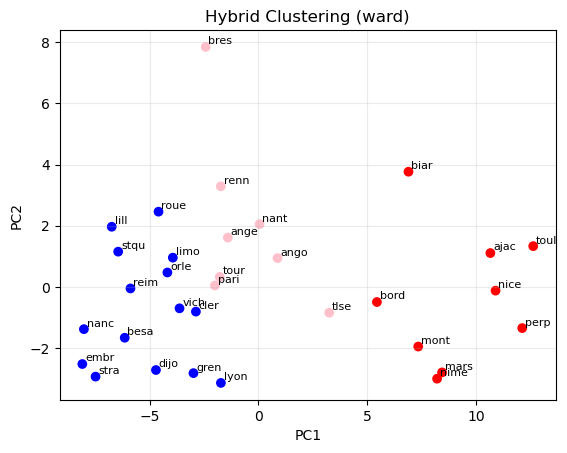

In [84]:
from numpy import sqrt


def hybrid_clustering(X, n_clusters=3, linkage="ward", random_state=42):
    # K-means d'abord avec un grand nombre de clusters
    nb_init_clusters = min(10, int(sqrt(len(X))))
    kmeans_init = KMeans(n_clusters=nb_init_clusters, random_state=random_state, n_init=10)
    labels_kmeans_init = kmeans_init.fit_predict(X)

    # Clustering hierarchique sur les centres initiaux
    init_centroids = kmeans_init.cluster_centers_
    agg = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
    labels_agg = agg.fit_predict(init_centroids)

    # K-means final en initialisant avec les centres des clusters hierarchiques
    final_centroids = np.array([init_centroids[labels_agg == c].mean(axis=0) for c in range(n_clusters)])
    kmeans_final = KMeans(n_clusters=n_clusters, init=final_centroids, n_init=1, random_state=random_state)
    final_labels = kmeans_final.fit_predict(X)

    return final_labels

print(hybrid_clustering(X, n_clusters=3, linkage="ward", random_state=42))

def show_hybrid(X, n_clusters=3, linkage="ward", random_state=42):
    labels_hybrid = hybrid_clustering(X, n_clusters=n_clusters, linkage=linkage, random_state=random_state)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hybrid, cmap=matplotlib.colors.ListedColormap(colors))
    for city, xp, yp in zip(labels, X_pca[:, 0], X_pca[:, 1]):
        plt.annotate(city, (xp, yp), textcoords="offset points", xytext=(2, 2), fontsize=8)
    plt.title(f"Hybrid Clustering ({linkage})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(alpha=0.25)
    plt.show()

show_hybrid(X, n_clusters=3, linkage="ward", random_state=42)


In [85]:
# Comparaison des scores de silhouette pour toutes les méthodes
def compare_methods(X, cluster_range):
    silhouette_scores_kmeans = {}
    silhouette_scores_agg_ward = {}
    silhouette_scores_agg_single = {}
    silhouette_scores_agg_average = {}
    silhouette_scores_hybrid = {}

    for k in range(*cluster_range):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels_k = km.fit_predict(X)
        silhouette_scores_kmeans[k] = silhouette_score(X, labels_k)

        agg_ward = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels_agg_ward = agg_ward.fit_predict(X)
        silhouette_scores_agg_ward[k] = silhouette_score(X, labels_agg_ward)

        agg_single = AgglomerativeClustering(n_clusters=k, linkage="single")
        labels_agg_single = agg_single.fit_predict(X)
        silhouette_scores_agg_single[k] = silhouette_score(X, labels_agg_single)

        agg_average = AgglomerativeClustering(n_clusters=k, linkage="average")
        labels_agg_average = agg_average.fit_predict(X)
        silhouette_scores_agg_average[k] = silhouette_score(X, labels_agg_average)

        labels_hybrid = hybrid_clustering(X, n_clusters=k, linkage="ward", random_state=42)
        silhouette_scores_hybrid[k] = silhouette_score(X, labels_hybrid)

    scores_df_all = pd.DataFrame({
        "n_clusters": list(silhouette_scores_kmeans.keys()),
        "KMeans": list(silhouette_scores_kmeans.values()),
        "Agglomerative (ward)": list(silhouette_scores_agg_ward.values()),
        "Agglomerative (single)": list(silhouette_scores_agg_single.values()),
        "Agglomerative (average)": list(silhouette_scores_agg_average.values()),
        "Hybrid": list(silhouette_scores_hybrid.values())
    }).sort_values("n_clusters")

    return scores_df_all

max_k = min(7, int(np.sqrt(len(X))) + 1)
method_comparison = compare_methods(X, cluster_range=(2, max_k))
method_comparison

,n_clusters,KMeans,Agglomerative (ward),Agglomerative (single),Agglomerative (average),Hybrid
0,2,0.618116,0.618116,0.165970,0.618116,0.618116
1,3,0.409120,0.406313,-0.022192,0.491728,0.409120
2,4,0.349404,0.370212,0.205581,0.368620,0.361240
3,5,0.326583,0.300232,0.424060,0.424060,0.326583


On peut réunir ces informations dans un graphe pour comparer :

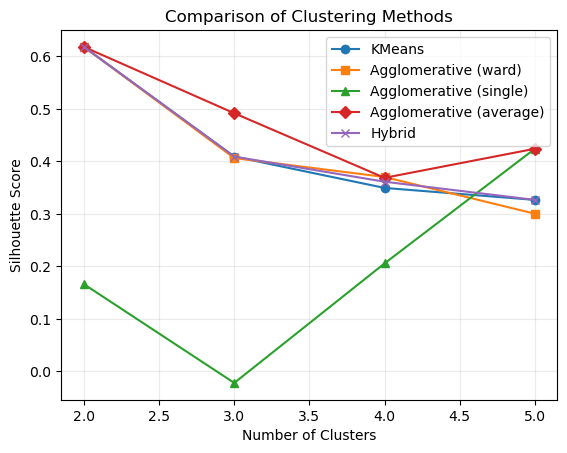

In [86]:
plt.plot(method_comparison["n_clusters"], method_comparison["KMeans"], label="KMeans", marker='o')
plt.plot(method_comparison["n_clusters"], method_comparison["Agglomerative (ward)"], label="Agglomerative (ward)", marker='s')
plt.plot(method_comparison["n_clusters"], method_comparison["Agglomerative (single)"], label="Agglomerative (single)", marker='^')
plt.plot(method_comparison["n_clusters"], method_comparison["Agglomerative (average)"], label="Agglomerative (average)", marker='D')
plt.plot(method_comparison["n_clusters"], method_comparison["Hybrid"], label="Hybrid", marker='x')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Comparison of Clustering Methods")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

On crée la fonction all-in-one

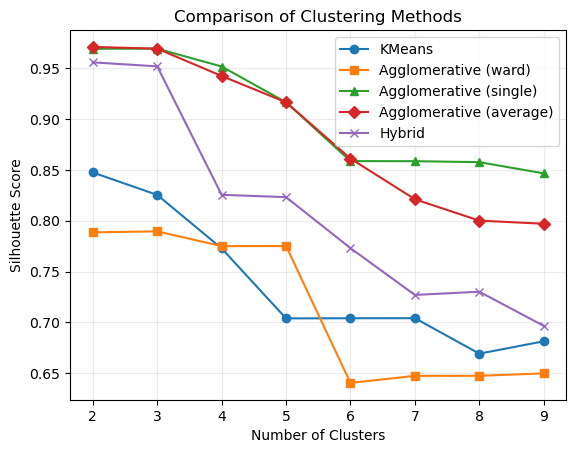

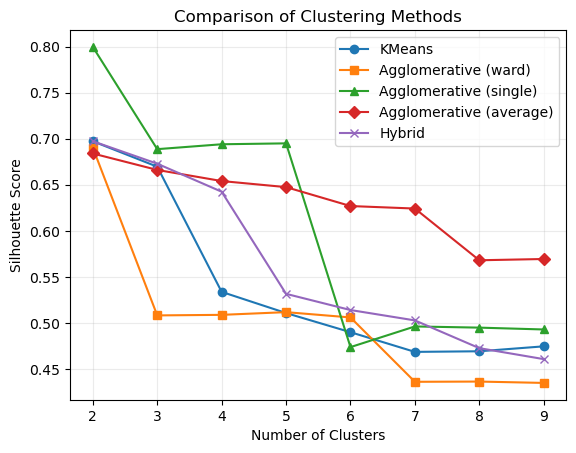

In [90]:
def compare_methods_file(filename: str):
    data = pd.read_csv(filename, sep=';')

    nb_columns = data.shape[1]

    X = data.iloc[:, 0:nb_columns].values

    custom_range = (2, min(10, int(np.sqrt(len(X))) + 1))

    method_comparison = compare_methods(X, cluster_range=custom_range)

    plt.plot(method_comparison["n_clusters"], method_comparison["KMeans"], label="KMeans", marker='o')
    plt.plot(method_comparison["n_clusters"], method_comparison["Agglomerative (ward)"], label="Agglomerative (ward)", marker='s')
    plt.plot(method_comparison["n_clusters"], method_comparison["Agglomerative (single)"], label="Agglomerative (single)", marker='^')
    plt.plot(method_comparison["n_clusters"], method_comparison["Agglomerative (average)"], label="Agglomerative (average)", marker='D')
    plt.plot(method_comparison["n_clusters"], method_comparison["Hybrid"], label="Hybrid", marker='x')
    plt.xlabel("Number of Clusters")
    plt.ylabel("Silhouette Score")
    plt.title("Comparison of Clustering Methods")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

compare_methods_file('./spamb.csv')
compare_methods_file('./wdbc.csv')